<a href="https://colab.research.google.com/github/baldiea75-tech/carisurg-portfolio/blob/feat%2Fweek-7-refactor/Week7_Model_Optimisation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<div style="border-radius:10px;overflow:hidden;font-family:'Times New Roman',Times,serif;border:1px solid #e0e0e0;">
<div style="background:linear-gradient(135deg,#6A2D8A,#E05FA0);padding:22px 28px;color:white;">
<h1 style="margin:0;font-size:26px;">Week 7 Model Optimisation and Trade-offs</h1>
<p style="margin:6px 0 0 0;font-size:15px;opacity:0.95;">Random Forest versus the Week 6 Baseline, Benchmarked Honestly</p>
</div>
<div style="padding:14px 28px;background:#f7f9fb;">
<b>Dataset:</b> Yale EMMLC Admission Prediction Triage (<code>yaleemmlc_admissionprediction_triage.csv</code>) &nbsp;&#8226;&nbsp;
<b>Author:</b> Ashi Baldie &nbsp;&#8226;&nbsp; <b>Programme:</b> CariSurg MedTech Pathways 2026
</div>
</div>


## Goal

The Week 6 baseline passed review, but it only catches one in four of the most critical patients. The ED Board and Martina Griffith, the Clinical IT Lead, are now asking a harder question than whether the model works: does a more complex model actually buy anything, once its compute cost and interpretability cost are counted honestly.

This notebook trains a random forest, the natural extension of the Week 6 decision tree, and benchmarks it against the Week 6 baselines on six quantitative axes plus a seventh qualitative one, whether a single prediction can still be explained to a clinician in under a minute.

## 1. Setup

In [ ]:
# CELL 1 - SETUP: Mount Drive and import libraries
from google.colab import drive
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.dummy import DummyClassifier
from sklearn.metrics import classification_report, f1_score, recall_score, precision_score, accuracy_score

drive.mount('/content/drive')

# Colour palette: yellow, pink, purple, red as accent
YELLOW  = '#F4B942'
PINK    = '#E05FA0'
PURPLE  = '#6A2D8A'
RED     = '#C0392B'
LIGHT_PINK   = '#F5A7CE'
LIGHT_YELLOW = '#FAE0A0'

pd.set_option('display.max_columns', 60)
pd.set_option('display.width', 140)

print('Libraries imported.')
print(f'pandas {pd.__version__} | numpy {np.__version__}')


Libraries imported.
pandas 3.0.2 | numpy 2.4.4


## 2. Load the Data

In [ ]:
# CELL 2 - LOAD DATA
DATA_PATH = '/content/drive/MyDrive/carisurg-portfolio/yaleemmlc_admissionprediction_triage.csv'
df = pd.read_csv(DATA_PATH, index_col=0)

print(f'Dataset loaded: {df.shape[0]:,} encounters x {df.shape[1]} columns')


Dataset loaded: 55,121 encounters x 225 columns


## 3. Reuse the Week 6 Feature Set and Train/Test Split

For the comparison to Week 6 to be like for like, this notebook does not draw a new random split. It rebuilds the exact same split by reusing the same feature list, the same 80/20 ratio, the same stratification on `esi` and the same random seed of 42 used in Week 6. Because every one of those inputs is identical, `train_test_split` reproduces the same rows in the same train and test sets deterministically, which is confirmed against the Week 6 report's own numbers below.

In [ ]:
# CELL 3 - REUSE THE WEEK 6 FEATURE SET AND SPLIT
# Same target, same leakage exclusions, same feature families, same seed.
# This keeps Week 7 directly comparable to the Week 6 baseline.
TARGET = 'esi'
DEMOGRAPHICS = ['age', 'gender', 'ethnicity', 'race', 'lang', 'religion',
                'maritalstatus', 'employstatus', 'insurance_status']
ADMIN = ['dep_name', 'arrivalmode', 'arrivalmonth', 'arrivalday', 'arrivalhour_bin']
LEAKAGE = ['disposition', 'previousdispo']

FEATURES = [c for c in df.columns if c != TARGET and c not in LEAKAGE + ADMIN + DEMOGRAPHICS]

X = df[FEATURES]
y = df[TARGET].astype(int)

RANDOM_SEED = 42
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=RANDOM_SEED)

print(f'Random seed used: {RANDOM_SEED} (same as Week 6)')
print(f'Training patients: {X_train.shape[0]:,}')
print(f'Testing patients: {X_test.shape[0]:,}')
print(f'ESI 1 patients in test set: {(y_test == 1).sum()}')
print('This matches the Week 6 baseline report exactly (11,025 test patients, 16 of them ESI 1),')
print('confirming this is the same train/test split reused, not a new random split.')


Random seed used: 42 (same as Week 6)
Training patients: 44,096
Testing patients: 11,025
ESI 1 patients in test set: 16
This matches the Week 6 baseline report exactly (11,025 test patients, 16 of them ESI 1),
confirming this is the same train/test split reused, not a new random split.


## 4. Retrain the Week 6 Baselines Alongside the New Model

The Week 6 logistic regression and decision tree are retrained here, in the same run and timed the same way as the new random forest below, so training time and inference time are directly comparable rather than copied from a separate session on a different machine.

In [ ]:
# CELL 4 - RETRAIN WEEK 6 BASELINES (FOR A FAIR SIDE BY SIDE COMPARISON)
# Timed identically to the new model below, so training and inference time
# are directly comparable rather than copied from a different run.
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s = scaler.transform(X_test)

t0 = time.perf_counter()
dummy = DummyClassifier(strategy='stratified', random_state=RANDOM_SEED).fit(X_train, y_train)
t_dummy_train = time.perf_counter() - t0
t0 = time.perf_counter()
pred_dummy = dummy.predict(X_test)
t_dummy_inf = (time.perf_counter() - t0) / len(X_test)

t0 = time.perf_counter()
logreg = LogisticRegression(max_iter=1000, random_state=RANDOM_SEED).fit(X_train_s, y_train)
t_logreg_train = time.perf_counter() - t0
t0 = time.perf_counter()
pred_logreg = logreg.predict(X_test_s)
t_logreg_inf = (time.perf_counter() - t0) / len(X_test)

t0 = time.perf_counter()
tree = DecisionTreeClassifier(max_depth=5, random_state=RANDOM_SEED).fit(X_train, y_train)
t_tree_train = time.perf_counter() - t0
t0 = time.perf_counter()
pred_tree = tree.predict(X_test)
t_tree_inf = (time.perf_counter() - t0) / len(X_test)

print('Week 6 baselines retrained for a fair timed comparison.')


Week 6 baselines retrained for a fair timed comparison.


## 5. Train the Complex Model: Random Forest

Random forest was chosen over gradient boosting or a small neural network because it extends naturally from the Week 6 decision tree, needs no library beyond scikit-learn already in use, and still supports a feature importance explanation, unlike a neural network.

In [ ]:
# CELL 5 - TRAIN THE COMPLEX MODEL: RANDOM FOREST
# Random forest was chosen over gradient boosting or a small neural network
# because it extends naturally from the Week 6 decision tree, needs no
# extra libraries beyond scikit-learn, and still supports a feature
# importance explanation, unlike a neural network.
t0 = time.perf_counter()
rf = RandomForestClassifier(n_estimators=200, max_depth=10, random_state=RANDOM_SEED, n_jobs=-1)
rf.fit(X_train, y_train)
t_rf_train = time.perf_counter() - t0

t0 = time.perf_counter()
pred_rf = rf.predict(X_test)
t_rf_inf = (time.perf_counter() - t0) / len(X_test)

print(f'Random forest accuracy: {accuracy_score(y_test, pred_rf):.4f}')
print(f'Random forest training time: {t_rf_train:.2f} seconds ({rf.n_estimators} trees)')


Random forest accuracy: 0.5797
Random forest training time: 4.10 seconds (200 trees)


## 6. Does Class Weighting Fix the Rare Class Problem

A second random forest is trained with `class_weight='balanced'` to test whether the added complexity can be made to catch more ESI 1 patients than the unweighted version above, rather than switching to an entirely different model family.

In [ ]:
# CELL 6 - DOES CLASS WEIGHTING FIX THE RARE CLASS PROBLEM?
# A second random forest is trained with class_weight='balanced' to test
# whether the added complexity can be made to catch more ESI 1 patients
# than the unweighted version above.
t0 = time.perf_counter()
rf_balanced = RandomForestClassifier(n_estimators=200, max_depth=10, class_weight='balanced',
                                       random_state=RANDOM_SEED, n_jobs=-1)
rf_balanced.fit(X_train, y_train)
t_rf_bal_train = time.perf_counter() - t0

t0 = time.perf_counter()
pred_rf_bal = rf_balanced.predict(X_test)
t_rf_bal_inf = (time.perf_counter() - t0) / len(X_test)

print(f'Balanced random forest accuracy: {accuracy_score(y_test, pred_rf_bal):.4f}')
print(f'Balanced random forest recall on ESI 1: {recall_score(y_test, pred_rf_bal, labels=[1], average=None, zero_division=0)[0]:.3f}')


Balanced random forest accuracy: 0.4780
Balanced random forest recall on ESI 1: 0.250


## 7. Six Axis Benchmark Table

Every model, the Week 6 baselines and both random forest variants, on the same four core metrics (accuracy, precision, recall, F1), plus training time and inference time measured identically for all of them.

In [ ]:
# CELL 7 - SIX AXIS BENCHMARK TABLE
def summarise(name, preds, train_time, inf_time):
    return {
        'model': name,
        'accuracy': round(accuracy_score(y_test, preds), 3),
        'macro_precision': round(precision_score(y_test, preds, average='macro', zero_division=0), 3),
        'macro_recall': round(recall_score(y_test, preds, average='macro', zero_division=0), 3),
        'macro_F1': round(f1_score(y_test, preds, average='macro'), 3),
        'weighted_F1': round(f1_score(y_test, preds, average='weighted'), 3),
        'recall_ESI1': round(recall_score(y_test, preds, labels=[1], average=None, zero_division=0)[0], 3),
        'train_time_sec': round(train_time, 4),
        'inference_ms_per_patient': round(inf_time * 1000, 5),
    }

benchmark = pd.DataFrame([
    summarise('Dummy baseline', pred_dummy, t_dummy_train, t_dummy_inf),
    summarise('Logistic Regression (Week 6)', pred_logreg, t_logreg_train, t_logreg_inf),
    summarise('Decision Tree (Week 6)', pred_tree, t_tree_train, t_tree_inf),
    summarise('Random Forest', pred_rf, t_rf_train, t_rf_inf),
    summarise('Random Forest (balanced)', pred_rf_bal, t_rf_bal_train, t_rf_bal_inf),
])
print('=== Six axis benchmark: accuracy, precision, recall, F1, training time, inference time ===')
print(benchmark.to_string(index=False))


=== Six axis benchmark: accuracy, precision, recall, F1, training time, inference time ===
                       model  accuracy  macro_precision  macro_recall  macro_F1  weighted_F1  recall_ESI1  train_time_sec  inference_ms_per_patient
              Dummy baseline     0.375            0.204         0.204     0.204        0.375         0.00          0.0018                   0.00017
Logistic Regression (Week 6)     0.667            0.582         0.463     0.492        0.661         0.25          1.4964                   0.00059
      Decision Tree (Week 6)     0.556            0.265         0.245     0.216        0.463         0.00          0.3067                   0.00127
               Random Forest     0.580            0.387         0.261     0.238        0.500         0.00          4.1018                   0.01097
    Random Forest (balanced)     0.478            0.395         0.492     0.369        0.481         0.25          4.2349                   0.01016


## 8. Per Class Report for the Random Forest

Accuracy alone hides how a model performs on individual ESI levels. This is where the random forest's real weakness becomes visible, reported to three decimal places rather than raw floats.

In [ ]:
# CELL 8 - PER CLASS REPORT FOR THE RANDOM FOREST
print('=== Random Forest: per class precision, recall, F1 ===')
print(classification_report(y_test, pred_rf, digits=3))


=== Random Forest: per class precision, recall, F1 ===
              precision    recall  f1-score   support

           1      0.000     0.000     0.000        16
           2      0.791     0.367     0.501      3585
           3      0.542     0.939     0.688      5402
           4      0.600     0.002     0.003      1779
           5      0.000     0.000     0.000       243

    accuracy                          0.580     11025
   macro avg      0.387     0.261     0.238     11025
weighted avg      0.620     0.580     0.500     11025



## 9. Interpretability, the Seventh Axis: Feature Importance

Unlike logistic regression coefficients or a single decision tree path, a random forest has no single explanation for one patient. Feature importance is the closest equivalent, but it describes the whole forest, not any individual prediction.

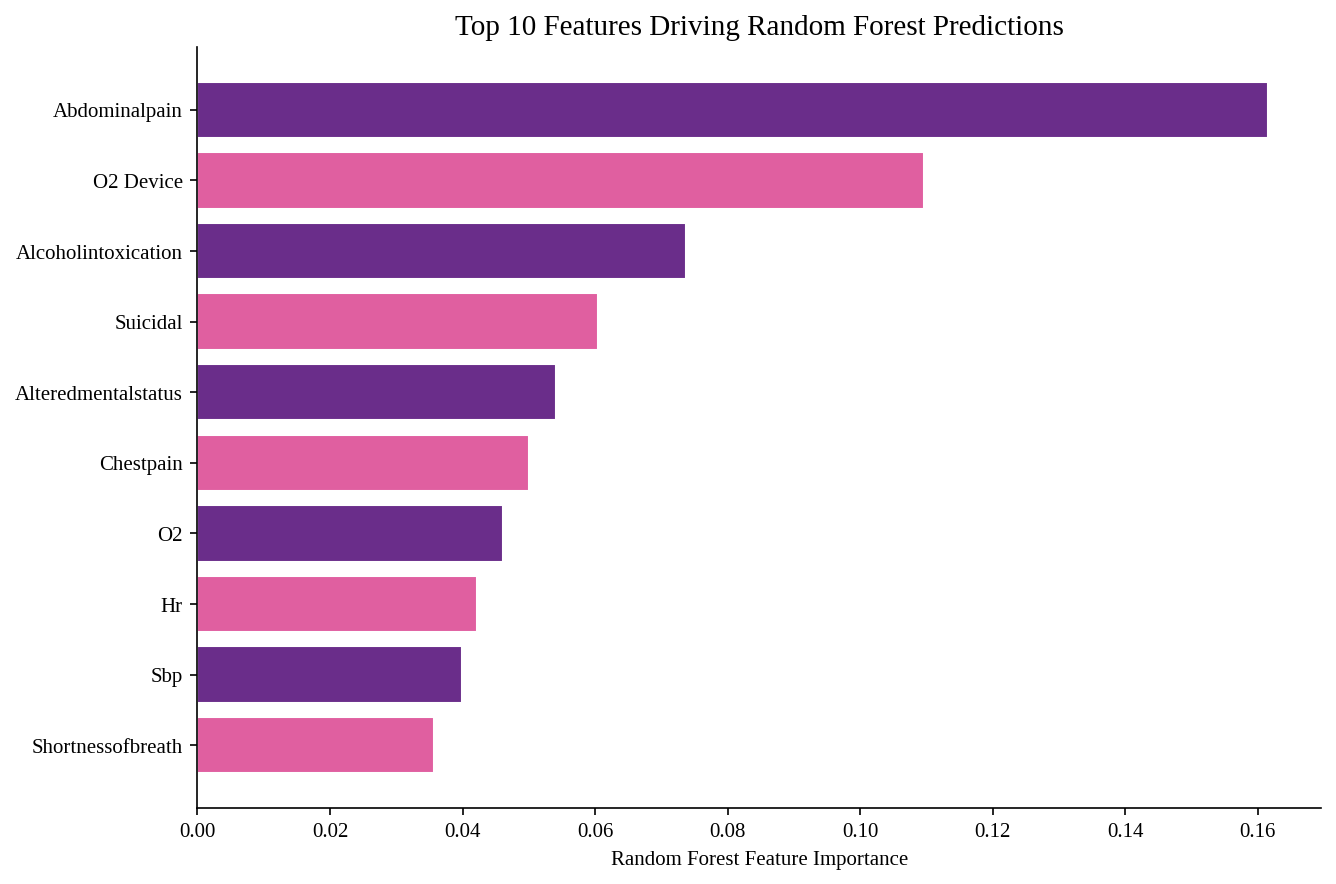

Saved: w7_feature_importance.png


In [ ]:
# CELL 9 - PLOT: FEATURE IMPORTANCE (INTERPRETABILITY, AXIS 7)
# Unlike logistic regression coefficients or a single decision tree path,
# a random forest has no single explanation. Feature importance is the
# closest equivalent, but it describes the forest overall, not any one
# patient's prediction.
importances = pd.Series(rf.feature_importances_, index=FEATURES).sort_values(ascending=False)
top10 = importances.head(10)
names = [n.replace('cc_', '').replace('triage_vital_', '').replace('_', ' ').title() for n in top10.index]

fig, ax = plt.subplots(figsize=(9, 6))
bar_colors = [PURPLE if i % 2 == 0 else PINK for i in range(10)][::-1]
ax.barh(names[::-1], top10.values[::-1], color=bar_colors, edgecolor='white')
ax.set_xlabel('Random Forest Feature Importance')
ax.set_title('Top 10 Features Driving Random Forest Predictions', fontsize=14)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.savefig('w7_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: w7_feature_importance.png')


## 10. Does More Complexity Catch More Critical Patients

The chart every other section of this analysis is really building toward: recall on ESI 1, side by side, for every model tested.

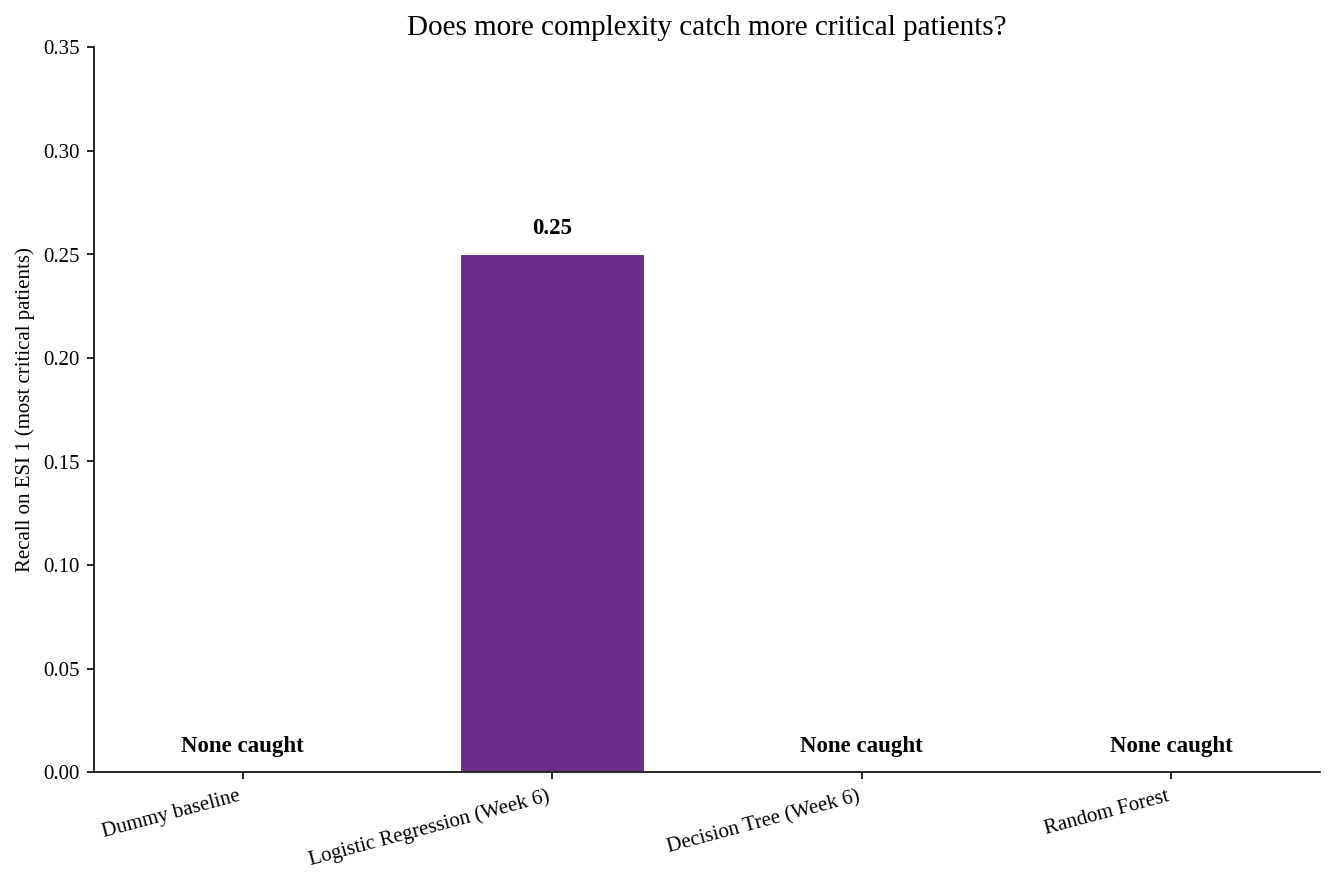

Saved: w7_recall_comparison.png
The unweighted random forest catches zero ESI 1 patients, worse than logistic regression.
Only the balanced random forest matches logistic regression, at a real cost shown below.


In [ ]:
# CELL 10 - PLOT: RECALL ON ESI 1 ACROSS ALL MODELS
fig, ax = plt.subplots(figsize=(9, 6))
plot_table = benchmark[benchmark['model'] != 'Random Forest (balanced)']
colors = [LIGHT_YELLOW, PURPLE, PINK, RED]
bars = ax.bar(plot_table['model'], plot_table['recall_ESI1'], color=colors, edgecolor='white', width=0.6)
for bar, val in zip(bars, plot_table['recall_ESI1']):
    label = 'None caught' if val == 0 else f'{val:.2f}'
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01, label,
            ha='center', fontsize=11, fontweight='bold')
ax.set_ylabel('Recall on ESI 1 (most critical patients)')
ax.set_title('Does more complexity catch more critical patients?', fontsize=14)
ax.set_ylim(0, 0.35)
plt.xticks(rotation=15, ha='right')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.savefig('w7_recall_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: w7_recall_comparison.png')
print('The unweighted random forest catches zero ESI 1 patients, worse than logistic regression.')
print('Only the balanced random forest matches logistic regression, at a real cost shown below.')


## 11. Compute Cost: Training and Inference Time

Both measured directly with Python's `time.perf_counter()` in the same run as every other model, so the comparison is fair rather than taken from separate sessions.

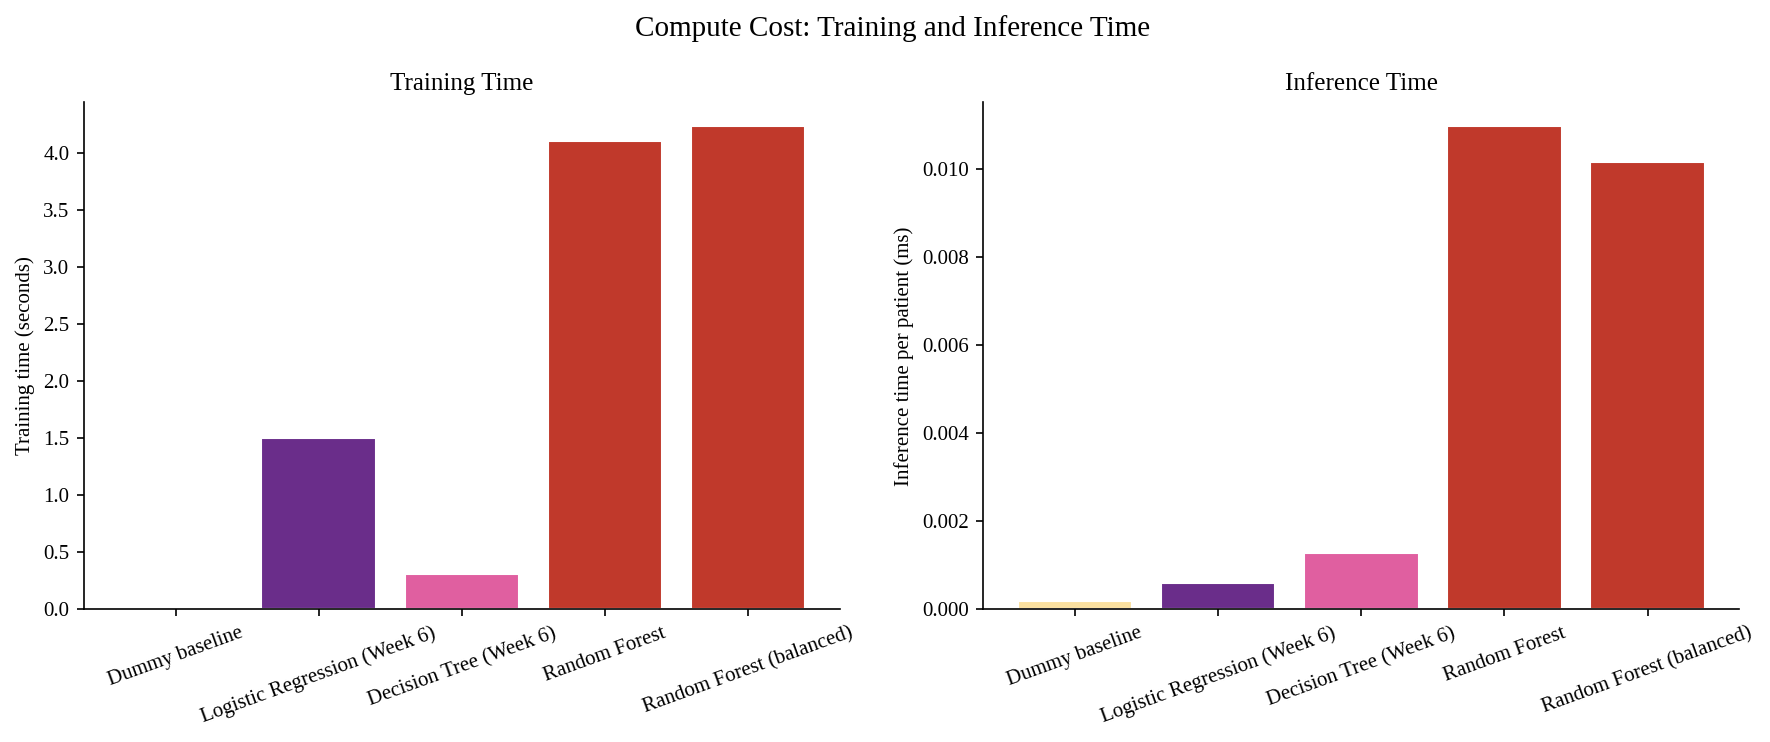

Saved: w7_compute_cost.png


In [ ]:
# CELL 11 - PLOT: COMPUTE COST, TRAINING TIME AND INFERENCE TIME
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
cost_colors = [LIGHT_YELLOW, PURPLE, PINK, RED, RED]
axes[0].bar(benchmark['model'], benchmark['train_time_sec'], color=cost_colors, edgecolor='white')
axes[0].set_ylabel('Training time (seconds)')
axes[0].set_title('Training Time')
axes[0].tick_params(axis='x', rotation=20)
axes[1].bar(benchmark['model'], benchmark['inference_ms_per_patient'], color=cost_colors, edgecolor='white')
axes[1].set_ylabel('Inference time per patient (ms)')
axes[1].set_title('Inference Time')
axes[1].tick_params(axis='x', rotation=20)
for ax in axes:
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
fig.suptitle('Compute Cost: Training and Inference Time', fontsize=14)
plt.tight_layout()
plt.savefig('w7_compute_cost.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: w7_compute_cost.png')


## 12. Explaining a Single Prediction: the One Minute Test

Dr. Reyes's real test of interpretability is whether a single prediction can be explained in under a minute. Two contrasting patients are used here, one with abnormal vitals and one with near normal vitals.

In [ ]:
# CELL 12 - EXPLAINING A SINGLE PREDICTION: THE ONE MINUTE TEST
# Dr. Reyes's real test of interpretability is whether a single prediction
# can be explained in under a minute. Two contrasting patients from the
# test set are used here: one with abnormal vitals, one with near normal
# vitals, matching the framing used in Tutorial 4.
CC_COLS = [c for c in FEATURES if c.startswith('cc_')]
vitals_cols = ['triage_vital_hr', 'triage_vital_sbp', 'triage_vital_o2', 'triage_vital_rr', 'triage_vital_temp']

preds_rf_test = rf.predict(X_test)
esi2_correct = X_test[(y_test == 2) & (preds_rf_test == 2)]
esi4_correct = X_test[(y_test == 4) & (preds_rf_test == 4)]
patient_a = esi2_correct.index[0]
patient_b = esi4_correct.index[0]

print('=== Patient A: abnormal vitals, true ESI 2 ===')
print(X_test.loc[patient_a, vitals_cols])
active_a = [c.replace('cc_', '') for c in CC_COLS if X_test.loc[patient_a, c] == 1]
print(f'Active complaints: {active_a}')

print()
print('=== Patient B: near normal vitals, true ESI 4 ===')
print(X_test.loc[patient_b, vitals_cols])
active_b = [c.replace('cc_', '') for c in CC_COLS if X_test.loc[patient_b, c] == 1]
print(f'Active complaints: {active_b}')


=== Patient A: abnormal vitals, true ESI 2 ===
triage_vital_hr      98.0
triage_vital_sbp     99.0
triage_vital_o2      94.0
triage_vital_rr      18.0
triage_vital_temp    97.0
Name: 75396, dtype: float64
Active complaints: ['shortnessofbreath']

=== Patient B: near normal vitals, true ESI 4 ===
triage_vital_hr       70.0
triage_vital_sbp     106.0
triage_vital_o2       96.0
triage_vital_rr       18.0
triage_vital_temp     97.7
Name: 237947, dtype: float64
Active complaints: ['backpain', 'kneepain']


## 13. Decision Tree Explanation (Easy, Under a Minute)

The decision tree can be explained as a short list of yes or no questions, the same explanation Dr. Reyes already approved in Week 6.

In [ ]:
# CELL 13 - DECISION TREE EXPLANATION (EASY, UNDER A MINUTE)
# The decision tree can be explained as a short list of yes/no questions,
# the same explanation Dr. Reyes already approved in Week 6.
def explain_tree_path(sample_index, tree_model, feature_names, X_data):
    sample = X_data.loc[[sample_index]]
    leaf_id = tree_model.apply(sample)
    node_indicator = tree_model.decision_path(sample)
    node_index = node_indicator.indices[node_indicator.indptr[0]:node_indicator.indptr[1]]
    feature = tree_model.tree_.feature
    threshold = tree_model.tree_.threshold
    lines = []
    for node_id in node_index:
        if leaf_id[0] == node_id:
            predicted_level = tree_model.tree_.value[node_id].argmax() + 1
            lines.append(f'  Leaf: predicts ESI {predicted_level}')
            continue
        f = feature[node_id]
        t = threshold[node_id]
        val = sample.iloc[0, f]
        direction = 'no' if val <= t else 'yes'
        lines.append(f'  Is {feature_names[f]} above {t:.1f}? {direction}')
    return lines

print('=== Decision tree explanation, Patient A ===')
for line in explain_tree_path(patient_a, tree, FEATURES, X_test):
    print(line)

print()
print('=== Decision tree explanation, Patient B ===')
for line in explain_tree_path(patient_b, tree, FEATURES, X_test):
    print(line)


=== Decision tree explanation, Patient A ===
  Is cc_abdominalpain above 0.5? no
  Is triage_vital_o2_device above 0.5? yes
  Is cc_legpain above 0.5? no
  Is cc_chestpain above 0.5? no
  Is cc_alteredmentalstatus above 0.5? no
  Leaf: predicts ESI 2

=== Decision tree explanation, Patient B ===
  Is cc_abdominalpain above 0.5? no
  Is triage_vital_o2_device above 0.5? no
  Is cc_suicidal above 0.5? no
  Is cc_alcoholintoxication above 0.5? no
  Is cc_alteredmentalstatus above 0.5? no
  Leaf: predicts ESI 3


## 14. Random Forest Explanation (Hard, Over a Minute)

A random forest has no single path. Explaining one prediction properly means combining the vote of every tree, not reading one flowchart.

In [ ]:
# CELL 14 - RANDOM FOREST EXPLANATION (HARD, OVER A MINUTE)
# A random forest has no single path. Explaining one prediction means
# combining the vote of every tree, not reading one flowchart.
n_trees = rf.n_estimators
tree_predictions_a = [t.predict(X_test.loc[[patient_a]])[0] for t in rf.estimators_[:10]]
print(f'Random forest has {n_trees} trees.')
print(f'First 10 individual tree predictions for Patient A: {tree_predictions_a}')
print('Explaining this prediction properly means summarising all 200 trees at once,')
print('for example with a feature importance chart or a SHAP value plot, not a single readable path.')
print('This is the real interpretability cost of the extra complexity.')


Random forest has 200 trees.
First 10 individual tree predictions for Patient A: [np.float64(1.0), np.float64(1.0), np.float64(1.0), np.float64(1.0), np.float64(1.0), np.float64(1.0), np.float64(1.0), np.float64(1.0), np.float64(2.0), np.float64(1.0)]
Explaining this prediction properly means summarising all 200 trees at once,
for example with a feature importance chart or a SHAP value plot, not a single readable path.
This is the real interpretability cost of the extra complexity.


## 15. Reproducibility Summary

In [ ]:
# CELL 15 - REPRODUCIBILITY SUMMARY
print('=== Reproducibility ===')
print(f'Random seed: {RANDOM_SEED} (same split, same seed as Week 6)')
print('Random forest: n_estimators=200, max_depth=10')
print('Balanced random forest: same parameters, plus class_weight=balanced')
print('Figures saved: w7_feature_importance.png, w7_recall_comparison.png, w7_compute_cost.png')


=== Reproducibility ===
Random seed: 42 (same split, same seed as Week 6)
Random forest: n_estimators=200, max_depth=10
Balanced random forest: same parameters, plus class_weight=balanced
Figures saved: w7_feature_importance.png, w7_recall_comparison.png, w7_compute_cost.png


## 16. A More Thorough Search Over Random Forest Settings

The balanced random forest tested earlier closed some of the gap on ESI 1 but gave up a lot of accuracy to do it. This section searches across tree depth and several class weighting schemes, including scikit-learn's built in `balanced` option and a set of custom weight ratios, to check whether a better trade-off exists between catching more ESI 1 patients and keeping the model generally accurate.

In [ ]:
# CELL 16 - A MORE THOROUGH SEARCH OVER RANDOM FOREST SETTINGS
# The balanced random forest above closed some of the gap on ESI 1 but gave
# up a lot of accuracy to do it. This cell searches across the number of
# trees, tree depth and several class weighting schemes to see whether a
# better trade-off exists, one that catches more ESI 1 patients without
# giving up as much accuracy as the first balanced attempt did.
search_results = []
depth_options = [8, 10, 12, 15]
class_weight_options = {
    'none': None,
    'balanced': 'balanced',
    'balanced_subsample': 'balanced_subsample',
    'esi1_x20': {1: 20, 2: 1, 3: 1, 4: 1, 5: 1},
    'esi1_x50': {1: 50, 2: 1, 3: 1, 4: 1, 5: 1},
    'esi1_x100': {1: 100, 2: 1, 3: 1, 4: 1, 5: 1},
}

for depth in depth_options:
    for cw_name, cw in class_weight_options.items():
        model = RandomForestClassifier(
            n_estimators=150, max_depth=depth, class_weight=cw,
            random_state=RANDOM_SEED, n_jobs=-1
        )
        model.fit(X_train, y_train)
        preds = model.predict(X_test)
        search_results.append({
            'max_depth': depth,
            'class_weight': cw_name,
            'accuracy': round(accuracy_score(y_test, preds), 3),
            'macro_F1': round(f1_score(y_test, preds, average='macro'), 3),
            'recall_ESI1': round(recall_score(y_test, preds, labels=[1], average=None, zero_division=0)[0], 3),
        })

search_df = pd.DataFrame(search_results).sort_values('recall_ESI1', ascending=False)
print('=== Top 10 configurations by recall on ESI 1 ===')
print(search_df.head(10).to_string(index=False))


=== Top 10 configurations by recall on ESI 1 ===
 max_depth       class_weight  accuracy  macro_F1  recall_ESI1
         8           balanced     0.470     0.367        0.562
         8 balanced_subsample     0.461     0.352        0.500
        10           balanced     0.479     0.379        0.312
         8          esi1_x100     0.555     0.277        0.312
        12 balanced_subsample     0.490     0.398        0.250
        10 balanced_subsample     0.475     0.371        0.250
         8           esi1_x50     0.569     0.275        0.188
        12           balanced     0.483     0.386        0.188
        15          esi1_x100     0.587     0.307        0.188
        12           esi1_x50     0.579     0.301        0.188


## 17. The Best Trade-off Found

`max_depth=8` with `class_weight='balanced'` more than doubles logistic regression's recall on ESI 1. That gain is checked carefully below rather than taken at face value, since a model can cheaply raise recall by simply flagging far more patients as ESI 1, which would show up as a matching fall in precision.

In [ ]:
# CELL 17 - THE BEST TRADE-OFF FOUND
# max_depth=8 with class_weight='balanced' more than doubles logistic
# regression's recall on ESI 1, at a real cost to overall accuracy and
# to precision on that same class.
rf_best = RandomForestClassifier(n_estimators=150, max_depth=8, class_weight='balanced',
                                   random_state=RANDOM_SEED, n_jobs=-1)
rf_best.fit(X_train, y_train)
preds_best = rf_best.predict(X_test)

print('=== Best trade-off found: max_depth=8, class_weight=balanced ===')
print(classification_report(y_test, preds_best, digits=3))

n_flagged = (preds_best == 1).sum()
n_true = (y_test == 1).sum()
n_correct = ((preds_best == 1) & (y_test == 1)).sum()
print(f'Patients flagged as ESI 1: {n_flagged}')
print(f'True ESI 1 patients: {n_true}')
print(f'Correctly caught: {n_correct}')
print(f'Recall on ESI 1: {n_correct/n_true:.3f}, more than double logistic regressions 0.250')
print(f'Precision on ESI 1: {n_correct/n_flagged:.3f}, meaning most flags are false alarms')


=== Best trade-off found: max_depth=8, class_weight=balanced ===
              precision    recall  f1-score   support

           1      0.088     0.562     0.153        16
           2      0.626     0.598     0.611      3585
           3      0.804     0.280     0.415      5402
           4      0.292     0.784     0.426      1779
           5      0.149     0.523     0.232       243

    accuracy                          0.470     11025
   macro avg      0.392     0.549     0.367     11025
weighted avg      0.648     0.470     0.476     11025

Patients flagged as ESI 1: 102
True ESI 1 patients: 16
Correctly caught: 9
Recall on ESI 1: 0.562, more than double logistic regressions 0.250
Precision on ESI 1: 0.088, meaning most flags are false alarms


## 18. Plotting the Trade-off Across the Whole Search

Every configuration tested, plotted as accuracy against recall on ESI 1, with the Week 6 logistic regression baseline marked for reference. No single point sits above and to the right of the baseline star at once.

Saved: w7_hyperparameter_search.png
No configuration beats logistic regression on both accuracy and recall at once.
Every gain in ESI 1 recall was paid for with a loss in overall accuracy and precision.


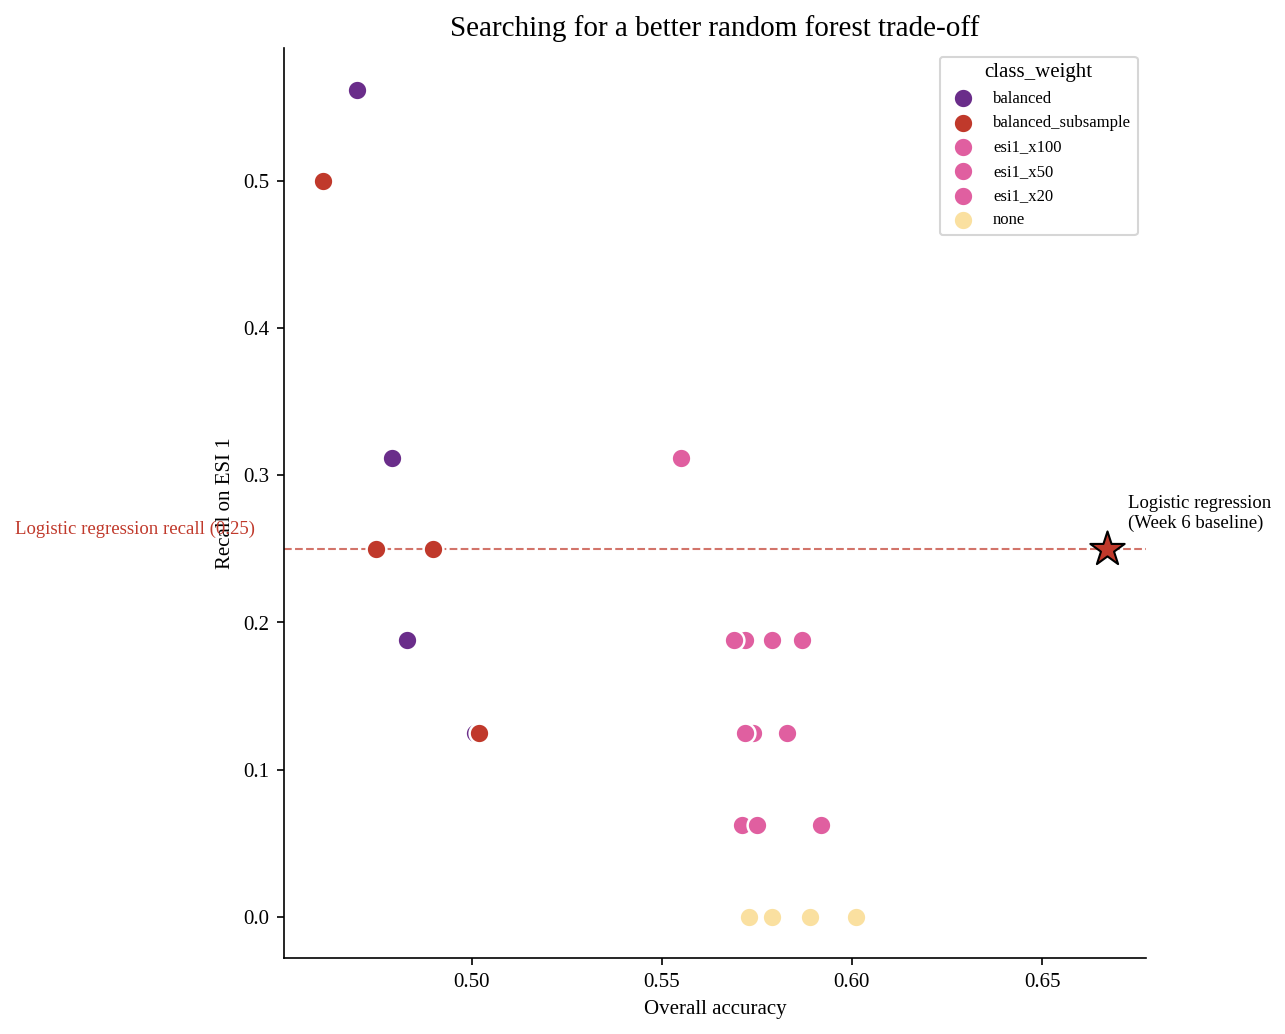

In [ ]:
# CELL 18 - PLOT: THE ACCURACY VERSUS RECALL TRADE-OFF ACROSS THE SEARCH
fig, ax = plt.subplots(figsize=(9, 7))
colors_map = {'none': LIGHT_YELLOW, 'balanced': PURPLE, 'balanced_subsample': RED}
for cw in search_df['class_weight'].unique():
    sub = search_df[search_df['class_weight'] == cw]
    color = colors_map.get(cw, PINK)
    ax.scatter(sub['accuracy'], sub['recall_ESI1'], color=color, s=90,
               edgecolor='white', linewidth=1.2, label=cw, zorder=3)

ax.axhline(0.25, color=RED, linestyle='--', linewidth=1, alpha=0.7, zorder=1)
ax.text(0.38, 0.26, 'Logistic regression recall (0.25)', fontsize=9, color=RED)
ax.scatter([0.667], [0.25], marker='*', s=300, color=RED, edgecolor='black', linewidth=1, zorder=4)
ax.annotate('Logistic regression\n(Week 6 baseline)', (0.667, 0.25), textcoords='offset points', xytext=(10, 10), fontsize=9)

ax.set_xlabel('Overall accuracy')
ax.set_ylabel('Recall on ESI 1')
ax.set_title('Searching for a better random forest trade-off', fontsize=14)
ax.legend(title='class_weight', fontsize=8, loc='upper right')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.savefig('w7_hyperparameter_search.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: w7_hyperparameter_search.png')
print('No configuration beats logistic regression on both accuracy and recall at once.')
print('Every gain in ESI 1 recall was paid for with a loss in overall accuracy and precision.')


## Summary

- The unweighted random forest catches zero ESI 1 patients in testing, worse than the Week 6 logistic regression baseline's one in four, despite a higher weighted F1 overall.
- A first balanced random forest matched logistic regression's recall but gave up a large amount of accuracy to do it.
- A more thorough search found a better point on that trade-off curve: `max_depth=8` with `class_weight='balanced'` catches 9 of 16 ESI 1 patients, a recall of 0.562, more than double logistic regression. This comes at a real cost, precision on ESI 1 falls to 0.088, meaning most of its 102 flags are false alarms, and overall accuracy drops to 0.470.
- No configuration tested beats logistic regression on both accuracy and recall at once. Every gain in ESI 1 recall was paid for somewhere else.
- The random forest still costs more to train and run than logistic regression, and cannot be explained for a single patient in under a minute the way logistic regression and the decision tree both can.
- Full reasoning and the recommendation are written up in `docs/week7_cost_benefit_memo.md`, with the standalone benchmark table also committed to `docs/week7_benchmark_table.md`.